In [10]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

@jax.custom_jvp
def spectral_circulant_matmul(x: jnp.ndarray, fft_full: jnp.ndarray) -> jnp.ndarray:
    padded_dim = fft_full.shape[0]
    single_example = x.ndim == 1
    if single_example:
        x = x[None, :]
    d_in = x.shape[-1]
    if d_in < padded_dim:
        pad_len = padded_dim - d_in
        x_pad = jnp.pad(x, ((0, 0), (0, pad_len)))
    elif d_in > padded_dim:
        x_pad = x[..., :padded_dim]
    else:
        x_pad = x
    X_fft = jnp.fft.fft(x_pad, axis=-1)
    y_fft = X_fft * fft_full[None, :]
    y = jnp.fft.ifft(y_fft, axis=-1).real
    if single_example:
        return y[0]
    return y

@spectral_circulant_matmul.defjvp
def spectral_circulant_matmul_jvp(primals, tangents):
    x, fft_full = primals
    dx, dfft = tangents
    padded_dim = fft_full.shape[0]

    single_example = x.ndim == 1
    if single_example:
        x = x[None, :]
        if dx is not None:
            dx = dx[None, :]
    d_in = x.shape[-1]
    if d_in < padded_dim:
        pad_len = padded_dim - d_in
        x_pad = jnp.pad(x, ((0, 0), (0, pad_len)))
        dx_pad = jnp.pad(dx, ((0, 0), (0, pad_len))) if dx is not None else None
    elif d_in > padded_dim:
        x_pad = x[..., :padded_dim]
        dx_pad = dx[..., :padded_dim] if dx is not None else None
    else:
        x_pad = x
        dx_pad = dx

    X_fft = jnp.fft.fft(x_pad, axis=-1)
    primal_y_fft = X_fft * fft_full[None, :]
    primal_y = jnp.fft.ifft(primal_y_fft, axis=-1).real

    if dx_pad is None:
        dX_fft = 0.0
    else:
        dX_fft = jnp.fft.fft(dx_pad, axis=-1)
    if dfft is None:
        term2 = 0.0
    else:
        term2 = X_fft * dfft[None, :]
    dY_fft = dX_fft * fft_full[None, :] + term2
    dY = jnp.fft.ifft(dY_fft, axis=-1).real

    if single_example:
        return primal_y[0], dY[0]
    return primal_y, dY

class SpectralCirculantLayer:
    def __init__(
        self,
        in_features: int,
        padded_dim: int = None,
        kernel_type: str = "power",
        alpha: float = None,
        alpha_prior=dist.HalfNormal(1),
        K: int = None,
        name: str = "spectral_circ_jvp",
        prior_fn=None,
        **kernel_kwargs
    ):
        """
        :param in_features: Input dimension.
        :param padded_dim: If provided, pad/truncate inputs to this dimension.
        :param kernel_type: Type of spectral density to use ("power", "rbf", "matern32", "matern52").
        :param alpha: For the "power" kernel, fixed value for the decay exponent; if None, a hyperprior is used.
        :param alpha_prior: Prior distribution for alpha if it is not fixed.
        :param K: Number of active frequencies to keep; if None, use full half-spectrum.
        :param name: Base name for NumPyro sample sites.
        :param prior_fn: Function mapping a scale to a distribution (default: Normal(0, scale)).
        :param kernel_kwargs: Additional parameters for the chosen kernel type (e.g. length_scale, variance, etc.).
        """
        self.in_features = in_features
        self.padded_dim = padded_dim if padded_dim is not None else in_features
        self.kernel_type = kernel_type.lower()
        self.alpha = alpha
        self.alpha_prior = alpha_prior
        self.name = name
        self.kernel_kwargs = kernel_kwargs

        # Length of half spectrum including DC (and Nyquist when applicable)
        self.k_half = (self.padded_dim // 2) + 1
        if (K is None) or (K > self.k_half):
            K = self.k_half
        self.K = K

        self.prior_fn = prior_fn if prior_fn is not None else (lambda scale: dist.Normal(0.0, scale))
        self._last_fft_full = None

    def compute_psd(self, freq_idx):
        """
        Compute the power spectral density (PSD) for a given array of frequency indices.
        Returns a vector of nonnegative values representing the variance allocated at each frequency.
        """
        if self.kernel_type == "power":
            # Use a power-law decay: PSD = 1 / (1 + f^alpha)
            if self.alpha is None:
                alpha = numpyro.sample(f"{self.name}_alpha", self.alpha_prior)
            else:
                alpha = self.alpha
            psd = 1.0 / (1.0 + freq_idx**alpha)
        elif self.kernel_type == "rbf":
            # PSD for RBF kernel: PSD = variance * exp(-2*pi^2*length_scale^2*f^2)
            length_scale = self.kernel_kwargs.get("length_scale", 1.0)
            variance = self.kernel_kwargs.get("variance", 1.0)
            psd = variance * jnp.exp(-2 * (jnp.pi**2) * (length_scale**2) * (freq_idx**2))
        elif self.kernel_type == "matern32":
            # A variant for Matern 3/2 kernel PSD:
            # PSD ∝ variance / (1 + (2*pi*length_scale*f)^2)^(2)
            length_scale = self.kernel_kwargs.get("length_scale", 1.0)
            variance = self.kernel_kwargs.get("variance", 1.0)
            psd = variance / (1.0 + (2*jnp.pi*length_scale*freq_idx)**2)**2
        elif self.kernel_type == "matern52":
            # A variant for Matern 5/2 kernel PSD:
            # PSD ∝ variance / (1 + (2*pi*length_scale*f)^2 + (2*pi*length_scale*f)^4)^(?)
            # This is one possible form.
            length_scale = self.kernel_kwargs.get("length_scale", 1.0)
            variance = self.kernel_kwargs.get("variance", 1.0)
            psd = variance / (1.0 + (2*jnp.pi*length_scale*freq_idx)**2 + (2*jnp.pi*length_scale*freq_idx)**4)
        else:
            raise ValueError(f"Unknown kernel type: {self.kernel_type}")
        return psd

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # Sample or fix alpha (only used in "power" kernel)
        if self.kernel_type == "power":
            if self.alpha is None:
                alpha = numpyro.sample(f"{self.name}_alpha", self.alpha_prior)
            else:
                alpha = self.alpha
        # Frequency indices for half spectrum
        freq_idx = jnp.arange(self.k_half, dtype=jnp.float32)
        # Compute theoretical PSD for these frequencies.
        theoretical_psd = self.compute_psd(freq_idx)
        # Convert PSD to standard deviations for the Gaussian prior:
        prior_std = jnp.sqrt(theoretical_psd)
        prior_std = jnp.clip(prior_std, a_min=1e-6)  # ensure no zero scales
        
        # Only sample active frequencies (truncation)
        active_idx = jnp.arange(self.K)
        active_real = numpyro.sample(
            f"{self.name}_real",
            self.prior_fn(prior_std[active_idx]).expand([self.K]).to_event(1),
        )
        active_imag = numpyro.sample(
            f"{self.name}_imag",
            self.prior_fn(prior_std[active_idx]).expand([self.K]).to_event(1),
        )

        # Construct full half-spectrum (fill unused frequencies with zero)
        full_real = jnp.zeros((self.k_half,), dtype=jnp.float32)
        full_imag = jnp.zeros((self.k_half,), dtype=jnp.float32)
        full_real = full_real.at[active_idx].set(active_real)
        full_imag = full_imag.at[active_idx].set(active_imag)

        # Enforce real-valued DC and (if even) Nyquist terms
        full_imag = full_imag.at[0].set(0.0)
        if (self.padded_dim % 2 == 0) and (self.k_half > 1):
            full_imag = full_imag.at[-1].set(0.0)

        half_complex = full_real + 1j * full_imag

        # Construct full Fourier coefficients via Hermitian symmetry
        if (self.padded_dim % 2 == 0) and (self.k_half > 1):
            nyquist = half_complex[-1].real[None]
            fft_full = jnp.concatenate(
                [half_complex[:-1], nyquist, jnp.conjugate(half_complex[1:-1])[::-1]]
            )
        else:
            fft_full = jnp.concatenate(
                [half_complex, jnp.conjugate(half_complex[1:])[::-1]]
            )

        self._last_fft_full = jax.lax.stop_gradient(fft_full)

        # Sample bias and add to output.
        bias = numpyro.sample(
            f"{self.name}_bias_spectral",
            dist.Normal(0.0, 1.0).expand([self.padded_dim]).to_event(1),
        )
        out = spectral_circulant_matmul(x, fft_full) + bias
        return out

    def get_fourier_coeffs(self) -> jnp.ndarray:
        if self._last_fft_full is None:
            raise ValueError("No Fourier coefficients available; call the layer first.")
        return self._last_fft_full

    def compute_covariance_kernel(self):
        """
        Compute the theoretical covariance kernel using the inverse FFT of the
        theoretical PSD. Here, the PSD is defined as that from compute_psd().
        This kernel represents the autocovariance function of the GP.
        """
        if self.kernel_type == "power" and self.alpha is None:
            raise ValueError("Alpha must be set to compute the covariance kernel.")
        freq_idx = jnp.arange(self.k_half, dtype=jnp.float32)
        theoretical_psd = self.compute_psd(freq_idx)
    
        # Build a full PSD vector with Hermitian symmetry.
        if (self.padded_dim % 2 == 0) and (self.k_half > 1):
            nyquist = theoretical_psd[-1][None]
            full_psd = jnp.concatenate(
                [theoretical_psd[:-1], nyquist, jnp.conjugate(theoretical_psd[1:-1])[::-1]]
            )
        else:
            full_psd = jnp.concatenate(
                [theoretical_psd, jnp.conjugate(theoretical_psd[1:])[::-1]]
            )
    
        # Compute the autocovariance function (kernel) via the inverse FFT of the PSD.
        kernel = jnp.fft.ifft(full_psd).real
        return kernel


In [19]:
import jax
import jax.random as jr
import numpy as np 
import time 
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from quantbayes import bnn
from quantbayes.fake_data import generate_regression_data 
from quantbayes.bnn.utils import BayesianAnalysis, evaluate_mcmc

df = generate_regression_data(n_continuous=64)
X, y = df.drop("target", axis=1), df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
y_train = jnp.array(y_train)
y_test = jnp.array(y_test)

class Test(bnn.Module):
    def __init__(self):
        super().__init__()
        self.fft_layer = SpectralCirculantLayer(
            64, 
            alpha=0.5,
            kernel_type="matern52",
            )
    def __call__(self, X, y=None):
        N, D = X.shape
        X = self.fft_layer(X)
        X = jax.nn.tanh(X)
        X = bnn.Linear(D, 1)(X)
        mu = X.squeeze()
        sigma = numpyro.sample("sigma", dist.Exponential(1.0))
        with numpyro.plate("data", N):
            numpyro.sample("logits", dist.Normal(mu, sigma), obs=y)

key = jr.key(0)
model = Test()
model.compile(num_warmup=300, num_samples=500)
tak = time.time()
model.fit(X_train, y_train, key)
tik = time.time()
preds = model.predict(X_test, key)
mean_preds = preds.mean(axis=0)
mse = mean_squared_error(np.array(y_test), np.array(mean_preds))
diagnostics = evaluate_mcmc(model)
bound = BayesianAnalysis(len(X_train), inference_type="mcmc", posterior_samples=model.get_samples)
bound.compute_pac_bayesian_bound(preds, y_test)
print(f"MSE: {mse:.3f}")
print(f"Time taken: {tik-tak:.3f}")
for key, value in diagnostics.items():
    print(key)
    print(value)

sample: 100%|██████████| 800/800 [02:58<00:00,  4.48it/s, 1023 steps of size 7.64e-04. acc. prob=0.92]
/Users/josephmargaryan/Desktop/quantbayes/venv/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Empirical risk: 0.082
Confidence term: 0.718
KL-Divergence: 822.588
Pac-Bayes Bound: 0.801
MSE: 0.042
Time taken: 178.786
elpd_waic
142.46
p_waic
17.73
waic_se
0.03
elpd_loo
142.30
p_loo
17.89
loo_se
0.03
avg_rhat
NaN
avg_ess
224.18
total_params
196


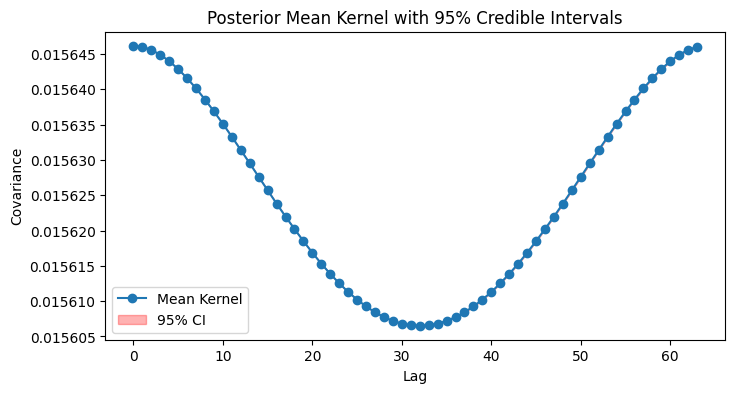

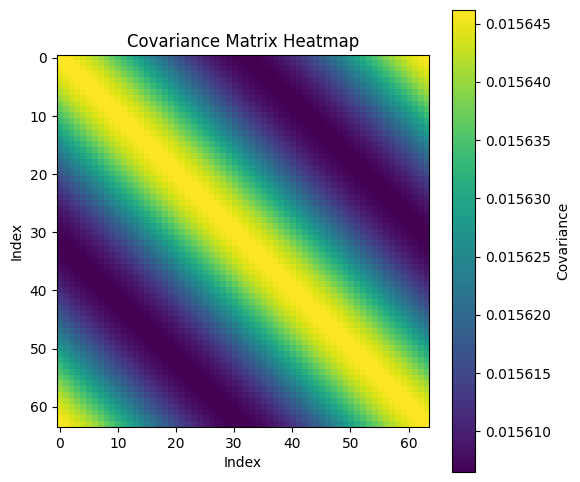

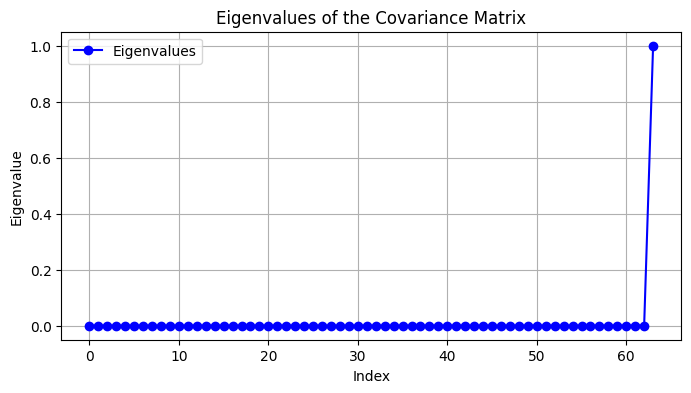

Minimum eigenvalue: -1.10827386e-07
Cholesky decomposition failed. The matrix might not be positive semidefinite.


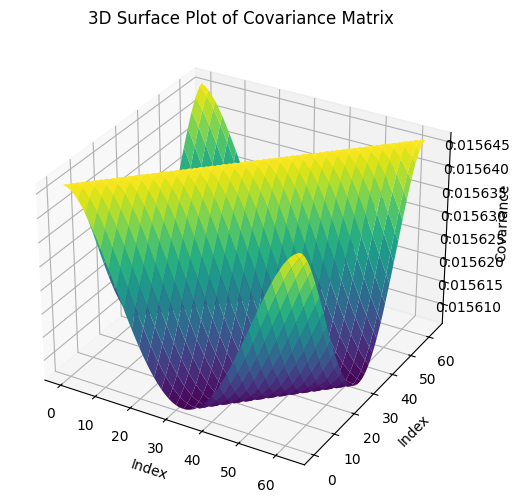

/var/folders/ch/74rww8ps6cx8x_ptd9fj5d400000gn/T/ipykernel_14615/3592259608.py:92: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, cov_matrix, size=n_samples)


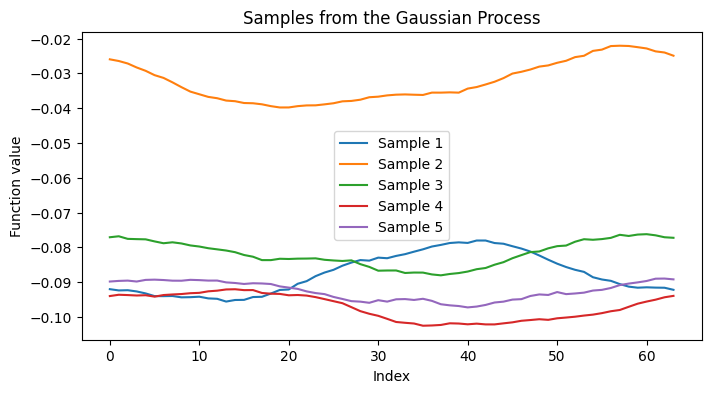

In [20]:
from numpyro import handlers
import jax.random as jr
import numpy as np
from scipy.linalg import toeplitz, cholesky, LinAlgError

def get_kernel_for_params(model, X, param_dict, rng_key=jr.PRNGKey(0)):
    """
    Substitute a concrete parameter set into the model and run one forward pass
    with a provided rng_key so that the sample sites receive valid keys.
    This triggers model.fft_layer to store its Fourier coefficients, from which
    we retrieve the kernel.
    """
    with handlers.seed(rng_seed=rng_key):
        with handlers.substitute(data=param_dict):
            _ = model(X)  # Run forward pass to set up Fourier coefficients.
    kernel = model.fft_layer.compute_covariance_kernel()
    return jax.device_get(kernel)

# Example: Collect kernel samples from posterior.
n_samples = 50  # number of posterior draws to analyze.
kernel_samples = []
posterior_samples = model.get_samples
for i in range(n_samples):
    sample_param_dict = {k: v[i] for k, v in posterior_samples.items()}
    kernel_sample = get_kernel_for_params(model, X_test, sample_param_dict, rng_key=jr.PRNGKey(i))
    kernel_samples.append(kernel_sample)
kernel_samples = np.stack(kernel_samples, axis=0)

# Compute the mean kernel and 95% credible intervals at each lag.
kernel_mean = np.mean(kernel_samples, axis=0)
kernel_lower = np.percentile(kernel_samples, 2.5, axis=0)
kernel_upper = np.percentile(kernel_samples, 97.5, axis=0)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(kernel_mean, label="Mean Kernel", marker="o")
plt.fill_between(np.arange(len(kernel_mean)), kernel_lower, kernel_upper, color="red", alpha=0.3, label="95% CI")
plt.xlabel("Lag")
plt.ylabel("Covariance")
plt.title("Posterior Mean Kernel with 95% Credible Intervals")
plt.legend()
plt.show()

cov_matrix = toeplitz(kernel_mean)

# 2. Heatmap of the covariance matrix.
plt.figure(figsize=(6, 6))
plt.imshow(cov_matrix, cmap="viridis", interpolation="none")
plt.title("Covariance Matrix Heatmap")
plt.xlabel("Index")
plt.ylabel("Index")
plt.colorbar(label="Covariance")
plt.show()

# 3. Eigenvalue Analysis: Plot the eigenvalues.
eigvals = np.linalg.eigvalsh(cov_matrix)
plt.figure(figsize=(8, 4))
plt.plot(eigvals, "bo-", label="Eigenvalues")
plt.title("Eigenvalues of the Covariance Matrix")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.legend()
plt.grid(True)
plt.show()

print("Minimum eigenvalue:", eigvals.min())

# 4. Cholesky Decomposition:
try:
    L = cholesky(cov_matrix, lower=True)
    print("Cholesky decomposition succeeded. The matrix is positive semidefinite.")
except LinAlgError:
    print("Cholesky decomposition failed. The matrix might not be positive semidefinite.")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
n = cov_matrix.shape[0]
X_grid, Y_grid = np.meshgrid(np.arange(n), np.arange(n))
ax.plot_surface(X_grid, Y_grid, cov_matrix, cmap="viridis", edgecolor="none")
ax.set_title("3D Surface Plot of Covariance Matrix")
ax.set_xlabel("Index")
ax.set_ylabel("Index")
ax.set_zlabel("Covariance")
plt.show()

# 5. Generate sample functions from the Gaussian process defined by the kernel.
# Here, we assume zero mean for simplicity.
n_points = len(kernel_mean)
n_samples = 5  # number of GP samples to generate
mean = np.zeros(n_points)
samples = np.random.multivariate_normal(mean, cov_matrix, size=n_samples)

plt.figure(figsize=(8, 4))
for i in range(n_samples):
    plt.plot(samples[i], label=f"Sample {i+1}")
plt.title("Samples from the Gaussian Process")
plt.xlabel("Index")
plt.ylabel("Function value")
plt.legend()
plt.show()

Power:
Empirical risk: 0.085
Confidence term: 0.429
KL-Divergence: 290.927
Pac-Bayes Bound: 0.513
MSE: 0.040
Time taken: 213.978
elpd_waic
115.77
p_waic
97.08
waic_se
0.02
elpd_loo
113.77
p_loo
99.08
loo_se
0.02
avg_rhat
NaN
avg_ess
115.17
total_params
196

rbf
Note The PSD is only zero
Empirical risk: 39.360
Confidence term: 1.303
KL-Divergence: 2713.978
Pac-Bayes Bound: 40.663
MSE: 38.056
Time taken: 221.045
elpd_waic
-13123.59
p_waic
0.00
waic_se
0.46
elpd_loo
nan
p_loo
nan
loo_se
nan
avg_rhat
NaN
avg_ess
344.79
total_params
196

matern32
Note Minimum eigenvalue: -6.798655e-08
Empirical risk: 0.077
Confidence term: 0.702
KL-Divergence: 785.471
Pac-Bayes Bound: 0.779
MSE: 0.038
Time taken: 181.404
elpd_waic
166.69
p_waic
17.82
waic_se
0.03
elpd_loo
166.54
p_loo
17.97
loo_se
0.03
avg_rhat
NaN
avg_ess
208.62
total_params
196

Matern52
Empirical risk: 0.082
Confidence term: 0.718
KL-Divergence: 822.588
Pac-Bayes Bound: 0.801
MSE: 0.042
Time taken: 178.786
elpd_waic
142.46
p_waic
17.73
waic_se
0.03
elpd_loo
142.30
p_loo
17.89
loo_se
0.03
avg_rhat
NaN
avg_ess
224.18
total_params
196